# Análisis exploratorio preliminar – SECOP II
**Bases:** Proponentes por Proceso SECOP II · Ubicaciones Adicionales SECOP II

El notebook es genérico: detecta columnas, tipos y llaves automáticamente, así que funciona aunque no conozcamos de antemano todas las columnas. Donde dice `COMPLETAR` hay que tomar una decisión después de ver los resultados.

**Orden de ejecución** (distinto a la numeración de los criterios, por dependencia lógica):
0. Carga CSV → Parquet · 1. Descripción de variables · 4. Limpieza · 2. Tendencia central y distribución · 3. Correlación · 6. Llaves · 5. Scatter (usa las llaves) · Bitácora de rendimiento

Cada etapa registra **tiempo, pico de RAM, filas y bytes** en una bitácora (requisito del curso).

In [14]:
# Ejecutar una sola vez
# !pip install -U polars pyarrow pandas matplotlib psutil

## Configuración

In [15]:
import os, re, gc, time, threading, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import psutil
import matplotlib.pyplot as plt

print("Polars", pl.__version__)   # se requiere versión 1.x

# COMPLETAR: rutas de los CSV en tu computador
RUTAS = {
    "proponentes": Path(r"C:/Users/carri/OneDrive - Universidad de la Sabana/Posgrado Analitica Aplicada/Semestre 1/Herramientas de Big Data/Proyecto/Exploracion Inicial Datos/Proponentes_por_Proceso_SECOP_II_20260923.csv"),
    "ubicaciones": Path(r"C:/Users/carri/OneDrive - Universidad de la Sabana/Posgrado Analitica Aplicada/Semestre 1/Herramientas de Big Data/Proyecto/Exploracion Inicial Datos/SECOP_II_-_Ubicaciones_Adicionales_20260923.csv"),
}
SALIDA = Path("eda_secop"); SALIDA.mkdir(exist_ok=True)

SEPARADOR = ","            # los CSV de datos.gov.co vienen separados por coma
MUESTRA_TIPOS = 50_000     # filas usadas para detectar tipos de columna
MUESTRA_ANALISIS = 300_000 # filas para gráficos y correlaciones (las estadísticas se calculan con TODO el conjunto)
SEMILLA = 42

# Textos que en la práctica significan "sin dato". Ajustar tras ver la sección 2 (modas / top 10).
PSEUDO_NULOS = ["", "No Definido", "No definido", "NO DEFINIDO", "N/A", "NULL", "null", "None"]

# Si la detección automática de tipos se equivoca, corregir aquí. Tipos: "id", "numero", "fecha", "texto"
# Ejemplo: {"proponentes": {"Valor Oferta": ("numero", None), "Fecha": ("fecha", "%m/%d/%Y")}}
TIPOS_MANUALES = {"proponentes": {}, "ubicaciones": {}}

pl.Config.set_tbl_rows(60); pl.Config.set_tbl_cols(20); pl.Config.set_fmt_str_lengths(60)
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 200)

Polars 1.44.2


## Utilidades: medición de rendimiento y detección de tipos

In [16]:
PROC = psutil.Process(os.getpid())
BITACORA = []

class Medir:
    '''Mide tiempo y pico de RAM del proceso de Python (incluye la memoria que usa Polars).'''
    def __init__(self, base, etapa):
        self.base, self.etapa, self.filas, self.bytes = base, etapa, None, None
    def __enter__(self):
        gc.collect()
        self.ram0 = self.pico = PROC.memory_info().rss
        self._on = True
        self._hilo = threading.Thread(target=self._vigilar, daemon=True); self._hilo.start()
        self.t0 = time.perf_counter()
        return self
    def _vigilar(self):
        while self._on:
            self.pico = max(self.pico, PROC.memory_info().rss); time.sleep(0.05)
    def __exit__(self, *exc):
        seg = time.perf_counter() - self.t0
        self._on = False; self._hilo.join()
        BITACORA.append({"base": self.base, "etapa": self.etapa, "segundos": round(seg, 2),
                         "ram_pico_mb": round(self.pico / 2**20, 1),
                         "ram_adicional_mb": round((self.pico - self.ram0) / 2**20, 1),
                         "filas": self.filas, "bytes": self.bytes})
        extra = (f" · {self.filas:,} filas" if self.filas is not None else "") + \
                (f" · {self.bytes / 2**20:,.1f} MB" if self.bytes is not None else "")
        print(f"[{self.base} | {self.etapa}] {seg:.1f} s · pico RAM {self.pico / 2**20:,.0f} MB{extra}")
        return False

def n_filas(lf):
    return lf.select(pl.len()).collect().item()

PATRON_ID = re.compile(r"\b(id|nit|c[oó]digo|documento|identificaci[oó]n|referencia|tel[eé]fono|url|portafolio)\b", re.I)
FORMATOS_FECHA = ["%m/%d/%Y %I:%M:%S %p", "%m/%d/%Y %H:%M:%S", "%m/%d/%Y",
                  "%Y-%m-%dT%H:%M:%S%.f", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%d/%m/%Y"]

def detectar_tipos(lf, manuales):
    '''Clasifica cada columna como id / numero / fecha / texto / vacia usando una muestra.'''
    muestra = lf.head(MUESTRA_TIPOS).collect()
    tipos = {}
    for c in muestra.columns:
        s = muestra[c].str.strip_chars()
        s = s.filter(s.is_not_null() & ~s.is_in(PSEUDO_NULOS))
        tipo, fmt = "texto", None
        if c in manuales:
            tipo, fmt = manuales[c]
        elif s.len() == 0:
            tipo = "vacia"
        elif PATRON_ID.search(c):
            tipo = "id"          # los identificadores (NIT, códigos) NO se tratan como números
        elif s.str.replace_all(r"[$\s]", "").cast(pl.Float64, strict=False).is_not_null().mean() >= 0.95:
            tipo = "numero"
        else:
            for f in FORMATOS_FECHA:
                if s.str.to_datetime(format=f, strict=False).is_not_null().mean() >= 0.95:
                    tipo, fmt = "fecha", f
                    break
        tipos[c] = (tipo, fmt)
    return tipos

def expr_limpio(c):
    '''Quita espacios y convierte pseudo-nulos en nulos reales.'''
    s = pl.col(c).str.strip_chars()
    return pl.when(s.is_in(PSEUDO_NULOS)).then(None).otherwise(s)

def tipar(lf, tipos):
    exprs = []
    for c, (t, f) in tipos.items():
        e = expr_limpio(c)
        if t == "numero":
            e = e.str.replace_all(r"[$\s]", "").cast(pl.Float64, strict=False)
        elif t == "fecha":
            e = e.str.to_datetime(format=f, strict=False)
        exprs.append(e.alias(c))
    return lf.select(exprs)

def slug(c):
    return re.sub(r"\W+", "_", c)

def cols_de(base, *tipos_buscados):
    return [c for c, (t, _) in TIPOS[base].items() if t in tipos_buscados]

def muestra_pd(lf, cols, n=MUESTRA_ANALISIS):
    df = lf.select(cols).collect()
    return df.sample(n=min(n, df.height), seed=SEMILLA).to_pandas()

def guardar_fig(fig, nombre):
    fig.tight_layout(); fig.savefig(SALIDA / nombre, dpi=150, bbox_inches="tight"); plt.show()

## 0. Carga: CSV → Parquet
Se lee el CSV **sin inferir tipos** (todo como texto, para no perder datos por errores de conversión) y se guarda en Parquet, que es columnar y comprimido: las etapas siguientes leen solo las columnas que necesitan y son mucho más rápidas. Se registra el tamaño del CSV y del Parquet.

In [17]:
CRUDO, TIPOS = {}, {}
for base, ruta in RUTAS.items():
    BITACORA.append({"base": base, "etapa": "Archivo CSV original", "bytes": ruta.stat().st_size})
    print(f"{base}: CSV de {ruta.stat().st_size / 2**20:,.1f} MB")
    destino = SALIDA / f"{base}_crudo.parquet"
    with Medir(base, "CSV → Parquet crudo") as m:
        lf = pl.scan_csv(ruta, separator=SEPARADOR, infer_schema_length=0, encoding="utf8-lossy",
                         truncate_ragged_lines=True, ignore_errors=True)
        lf = lf.rename({c: c.strip() for c in lf.collect_schema().names()})
        try:
            lf.sink_parquet(destino)              # procesamiento por bloques (streaming)
        except Exception as e:
            print("   sink_parquet falló, se usa collect():", e)
            lf.collect().write_parquet(destino)
        CRUDO[base] = pl.scan_parquet(destino)
        m.filas, m.bytes = n_filas(CRUDO[base]), destino.stat().st_size
    TIPOS[base] = detectar_tipos(CRUDO[base], TIPOS_MANUALES.get(base, {}))

proponentes: CSV de 593.0 MB
[proponentes | CSV → Parquet crudo] 1.1 s · pico RAM 1,879 MB · 2,318,975 filas · 102.1 MB
ubicaciones: CSV de 1,234.5 MB
[ubicaciones | CSV → Parquet crudo] 2.9 s · pico RAM 1,880 MB · 6,081,717 filas · 124.5 MB


## 1. Descripción de variables y propósito de cada base
Se genera un diccionario de datos por base (`eda_secop/diccionario_<base>.csv`) con tipo detectado, nulos, valores únicos y un ejemplo. **La columna `proposito` se completa a mano** usando la descripción de cada columna en la página del conjunto en datos.gov.co (sección "Columnas en este conjunto de datos").

Revisar también la columna `tipo`: si algo quedó mal clasificado, corregirlo en `TIPOS_MANUALES` y volver a ejecutar desde la sección 0.

In [18]:
DESC = {}
for base in RUTAS:
    lf, cols = CRUDO[base], list(TIPOS[base])
    with Medir(base, "1. Descripción de variables") as m:
        n = n_filas(lf)
        r = lf.select([pl.col(c).null_count().alias(f"nul|{c}") for c in cols]
                      + [pl.col(c).n_unique().alias(f"uni|{c}") for c in cols]
                      + [pl.col(c).drop_nulls().first().alias(f"ej|{c}") for c in cols]).collect().row(0, named=True)
        m.filas = n
    tabla = pd.DataFrame([{
        "columna": c, "tipo": TIPOS[base][c][0], "formato_fecha": TIPOS[base][c][1],
        "nulos": r[f"nul|{c}"], "pct_nulos": round(100 * r[f"nul|{c}"] / n, 2),
        "valores_unicos": r[f"uni|{c}"], "pct_unicos": round(100 * r[f"uni|{c}"] / n, 2),
        "ejemplo": str(r[f"ej|{c}"])[:60], "proposito": ""} for c in cols])
    DESC[base] = tabla
    tabla.to_csv(SALIDA / f"diccionario_{base}.csv", index=False, encoding="utf-8-sig")
    print(f"\n=== {base.upper()}: {n:,} filas × {len(cols)} columnas ===")
    display(tabla)

[proponentes | 1. Descripción de variables] 0.7 s · pico RAM 1,296 MB · 2,318,975 filas

=== PROPONENTES: 2,318,975 filas × 9 columnas ===


,columna,tipo,formato_fecha,nulos,pct_nulos,valores_unicos,pct_unicos,ejemplo,proposito
0,ID Procedimiento,id,NaN,0,0.0,697742,30.09,CO1.REQ.10159505,
1,Fecha Publicación,fecha,%m/%d/%Y,16180,0.7,3742,0.16,02/11/2026,
2,Nombre Procedimiento,texto,NaN,0,0.0,544795,23.49,SUMINISTRO DE PAÑALES DESECHABLES Y PAÑITOS Hu...,
3,NIT Entidad,id,NaN,0,0.0,4370,0.19,"901,541,245",
4,Codigo Entidad,id,NaN,0,0.0,5020,0.22,"702,962,226",
5,Entidad Compradora,texto,NaN,0,0.0,4997,0.22,ESM BATALLoN ASPC NO. 6,
6,Proveedor,texto,NaN,0,0.0,318073,13.72,INTERCOMERCIAL MEDICA,
7,NIT Proveedor,id,NaN,0,0.0,145572,6.28,830501223,
8,Codigo Proveedor,id,NaN,0,0.0,339274,14.63,700.150.014,


[ubicaciones | 1. Descripción de variables] 1.5 s · pico RAM 2,239 MB · 6,081,717 filas

=== UBICACIONES: 6,081,717 filas × 11 columnas ===


,columna,tipo,formato_fecha,nulos,pct_nulos,valores_unicos,pct_unicos,ejemplo,proposito
0,ID Contrato,id,None,0,0.00,6081717,100.00,CO1.PCCNTR.7475917,
1,Referencia Contrato,id,None,1,0.00,4465372,73.42,CO1.PCCNTR.7475917,
2,NIT Entidad,id,None,0,0.00,5798,0.10,899.999.027,
3,Nombre Entidad,texto,None,0,0.00,6469,0.11,DANE - TERRITORIAL CENTRO ORIENTE,
4,Codigo Entidad,id,None,0,0.00,6524,0.11,702.848.847,
5,Departamento,texto,None,0,0.00,1002,0.02,BUCARAMANGA,
6,Ciudad,texto,None,0,0.00,981,0.02,SANTANDER,
7,Dirección,texto,None,15039,0.25,11032,0.18,No Provisto,
8,Departamento Original,texto,None,0,0.00,1002,0.02,BUCARAMANGA,
9,Ciudad Original,texto,None,0,0.00,981,0.02,SANTANDER,


## 4. Limpieza: nulos, ceros y duplicados
Se hace antes de las estadísticas para que estas se calculen sobre datos coherentes. El reporte distingue:
- **nulos**: celdas vacías en el archivo original.
- **pseudo_nulos**: textos como "No Definido" que equivalen a no tener dato.
- **fallos_conversion**: valores que no pudieron leerse como número o fecha (revisarlos: pueden indicar un formato distinto).
- **ceros / negativos**: solo en columnas numéricas; un cero puede ser un dato real o un faltante disfrazado.

Decisiones de limpieza aplicadas: quitar espacios, convertir pseudo-nulos a nulos, eliminar columnas 100 % vacías y eliminar filas duplicadas exactas. **No se eliminan filas con nulos ni se imputan valores**: esa decisión depende del enfoque que elija el grupo.

[proponentes | 4. Diagnóstico de calidad] 1.7 s · pico RAM 2,794 MB · 2,318,975 filas

=== PROPONENTES === filas: 2,318,975 · duplicadas exactas: 35,534 (1.53 %)


,columna,tipo,nulos,pseudo_nulos,fallos_conversion,nulos_totales,pct_nulos_totales,ceros,negativos
0,ID Procedimiento,id,0,0,0,0,0.00,None,None
1,Fecha Publicación,fecha,16180,0,0,16180,0.70,None,None
2,Nombre Procedimiento,texto,0,0,0,0,0.00,None,None
3,NIT Entidad,id,0,0,0,0,0.00,None,None
4,Codigo Entidad,id,0,0,0,0,0.00,None,None
5,Entidad Compradora,texto,0,0,0,0,0.00,None,None
6,Proveedor,texto,0,5,0,5,0.00,None,None
7,NIT Proveedor,id,0,238197,0,238197,10.27,None,None
8,Codigo Proveedor,id,0,0,0,0,0.00,None,None


[proponentes | 4. Escritura Parquet limpio] 1.6 s · pico RAM 3,530 MB · 2,283,441 filas · 106.5 MB


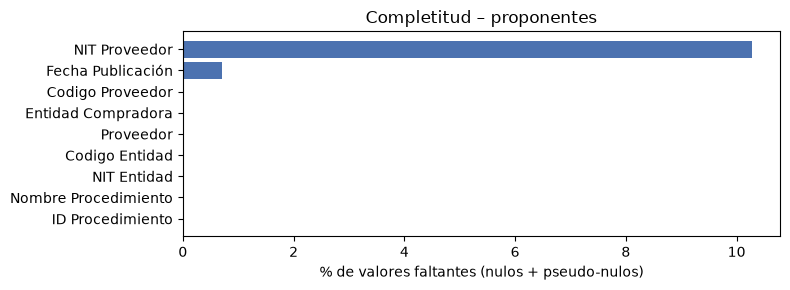

[ubicaciones | 4. Diagnóstico de calidad] 5.8 s · pico RAM 4,177 MB · 6,081,717 filas

=== UBICACIONES === filas: 6,081,717 · duplicadas exactas: 0 (0.00 %)


,columna,tipo,nulos,pseudo_nulos,fallos_conversion,nulos_totales,pct_nulos_totales,ceros,negativos
0,ID Contrato,id,0,0,0,0,0.00,None,None
1,Referencia Contrato,id,1,142,0,143,0.00,None,None
2,NIT Entidad,id,0,0,0,0,0.00,None,None
3,Nombre Entidad,texto,0,0,0,0,0.00,None,None
4,Codigo Entidad,id,0,0,0,0,0.00,None,None
5,Departamento,texto,0,125579,0,125579,2.06,None,None
6,Ciudad,texto,0,42317,0,42317,0.70,None,None
7,Dirección,texto,15039,0,0,15039,0.25,None,None
8,Departamento Original,texto,0,0,0,0,0.00,None,None
9,Ciudad Original,texto,0,0,0,0,0.00,None,None


[ubicaciones | 4. Escritura Parquet limpio] 3.4 s · pico RAM 4,524 MB · 6,081,717 filas · 128.5 MB


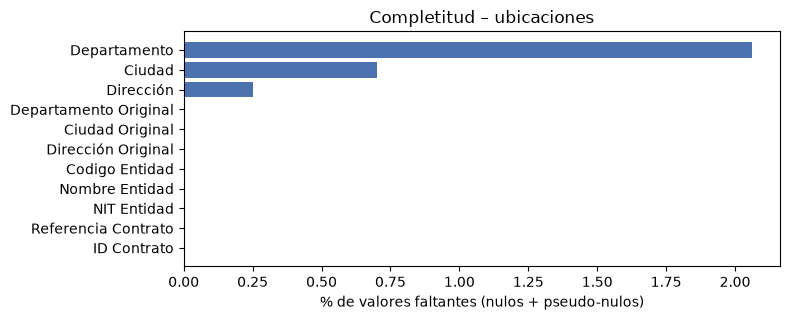

In [19]:
LIMPIO, CALIDAD = {}, {}
for base in RUTAS:
    crudo, tipos = CRUDO[base], TIPOS[base]
    tipado = tipar(crudo, tipos)
    cols, nums = list(tipos), cols_de(base, "numero")
    with Medir(base, "4. Diagnóstico de calidad") as m:
        n = n_filas(crudo)
        a = crudo.select([pl.col(c).null_count().alias(f"nul|{c}") for c in cols]
                         + [(pl.col(c).is_not_null() & pl.col(c).str.strip_chars().is_in(PSEUDO_NULOS)).sum().alias(f"ps|{c}")
                            for c in cols]).collect().row(0, named=True)
        b = tipado.select([pl.col(c).null_count().alias(f"nt|{c}") for c in cols]
                          + [(pl.col(c) == 0).sum().alias(f"cero|{c}") for c in nums]
                          + [(pl.col(c) < 0).sum().alias(f"neg|{c}") for c in nums]).collect().row(0, named=True)
        dup = n - tipado.select(pl.struct(pl.all()).hash().n_unique()).collect().item()
        m.filas = n
    rep = pd.DataFrame([{
        "columna": c, "tipo": tipos[c][0],
        "nulos": a[f"nul|{c}"], "pseudo_nulos": a[f"ps|{c}"],
        "fallos_conversion": b[f"nt|{c}"] - a[f"nul|{c}"] - a[f"ps|{c}"],
        "nulos_totales": b[f"nt|{c}"], "pct_nulos_totales": round(100 * b[f"nt|{c}"] / n, 2),
        "ceros": b.get(f"cero|{c}"), "negativos": b.get(f"neg|{c}")} for c in cols])
    CALIDAD[base] = rep
    rep.to_csv(SALIDA / f"calidad_{base}.csv", index=False, encoding="utf-8-sig")
    print(f"\n=== {base.upper()} === filas: {n:,} · duplicadas exactas: {dup:,} ({100 * dup / n:.2f} %)")
    display(rep)

    vacias = rep.loc[rep["nulos_totales"] == n, "columna"].tolist()
    if vacias: print("Columnas 100 % vacías (se eliminan):", vacias)
    destino = SALIDA / f"{base}_limpio.parquet"
    with Medir(base, "4. Escritura Parquet limpio") as m:
        final = tipado.drop(vacias).unique()
        try:
            final.sink_parquet(destino)
        except Exception as e:
            print("   sink_parquet falló, se usa collect():", e)
            final.collect().write_parquet(destino)
        LIMPIO[base] = pl.scan_parquet(destino)
        m.filas, m.bytes = n_filas(LIMPIO[base]), destino.stat().st_size
    for c in vacias: TIPOS[base].pop(c)

    # Gráfico: % de nulos por columna
    rep_g = rep.sort_values("pct_nulos_totales")
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(rep_g))))
    ax.barh(rep_g["columna"], rep_g["pct_nulos_totales"], color="#4C72B0")
    ax.set_xlabel("% de valores faltantes (nulos + pseudo-nulos)"); ax.set_title(f"Completitud – {base}")
    guardar_fig(fig, f"nulos_{base}.png")

## 2. Medidas de tendencia central y distribución
- **Numéricas**: media, mediana, moda, desviación estándar, coeficiente de variación, cuartiles, asimetría y atípicos por regla de 1,5 × RIC (calculadas con **todo** el conjunto). Histograma y diagrama de caja con una muestra; si la variable es muy asimétrica (típico en valores de contratos) se grafica en escala logarítmica.
- **Fechas**: rango y número de registros por año.
- **Categóricas**: número de categorías, moda y top 10.

Si una base no tiene variables numéricas, es normal en tablas de relación (proceso–proponente). En la sección 5 se construyen variables numéricas agregadas (p. ej. número de proponentes por proceso).


==================== PROPONENTES ====================
Sin variables numéricas en esta base.
Fecha 'Fecha Publicación': desde 2015-02-14 00:00:00 hasta 2026-09-22 00:00:00


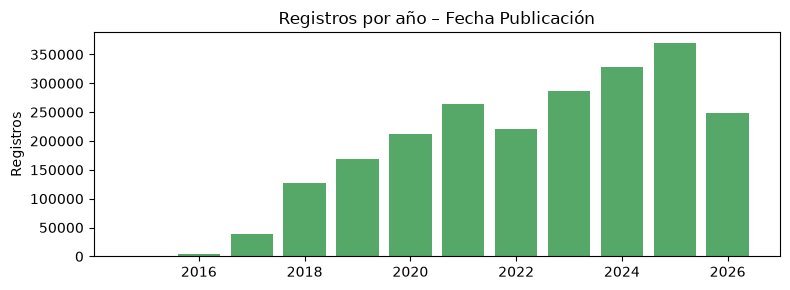

[proponentes | 2. Estadísticos categóricos] 0.5 s · pico RAM 1,769 MB · 2,283,441 filas


,columna,categorias,moda,frec_moda,pct_moda
0,Nombre Procedimiento,544786,CCE-05-CONTRATACION_DIRECTA,15800,0.69
1,Entidad Compradora,4997,INVIAS,99575,4.36
2,Proveedor,318072,CRR SOLUCIONES INTEGRALES S.A.S,17144,0.75



==================== UBICACIONES ====================
Sin variables numéricas en esta base.
[ubicaciones | 2. Estadísticos categóricos] 0.8 s · pico RAM 1,689 MB · 6,081,717 filas


,columna,categorias,moda,frec_moda,pct_moda
0,Nombre Entidad,6469,(Secretaría Distrital de Integración Social),97736,1.61
1,Departamento,1001,BOGOTa,1001600,16.47
2,Ciudad,980,DISTRITO CAPITAL DE BOGOTa,1134145,18.65
3,Dirección,11031,No Provisto,5470945,89.96
4,Departamento Original,1002,BOGOTa,1001600,16.47
5,Ciudad Original,981,DISTRITO CAPITAL DE BOGOTa,1134145,18.65
6,Dirección Original,5454,CRA 7 32 16,97736,1.61


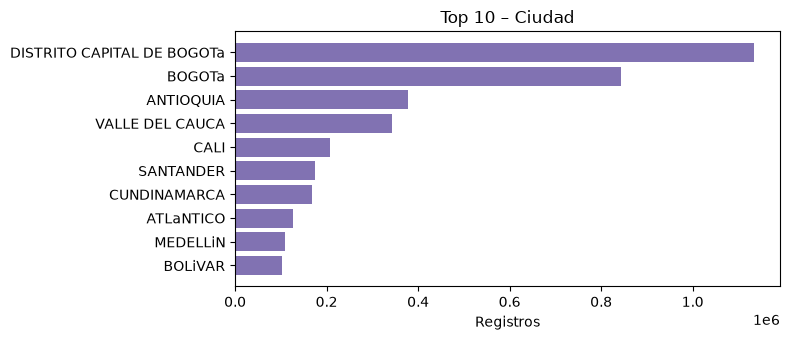

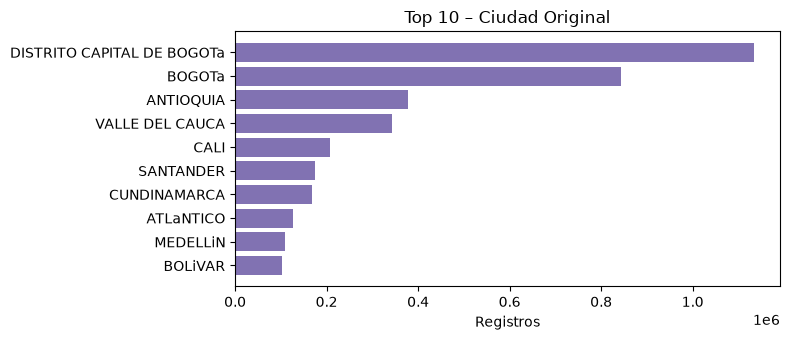

In [20]:
MAX_GRAF_CAT = 10
for base in RUTAS:
    lf, n = LIMPIO[base], n_filas(LIMPIO[base])
    nums, fechas = cols_de(base, "numero"), cols_de(base, "fecha")
    cats = [c for c in cols_de(base, "texto")]
    print(f"\n==================== {base.upper()} ====================")

    # --- Numéricas ---
    if nums:
        with Medir(base, "2. Estadísticos numéricos") as m:
            ex = []
            for c in nums:
                x = pl.col(c)
                ex += [x.count().alias(f"{c}|n"), x.mean().alias(f"{c}|media"), x.median().alias(f"{c}|mediana"),
                       x.mode().first().alias(f"{c}|moda"), x.std().alias(f"{c}|desv_est"), x.min().alias(f"{c}|min"),
                       x.quantile(0.25).alias(f"{c}|q1"), x.quantile(0.75).alias(f"{c}|q3"), x.max().alias(f"{c}|max"),
                       x.skew().alias(f"{c}|asimetria")]
            r = lf.select(ex).collect().row(0, named=True)
            m.filas = n
        est = pd.DataFrame([{k.split("|", 1)[1]: v for k, v in r.items() if k.split("|", 1)[0] == c} for c in nums], index=nums)
        est["cv"] = est["desv_est"] / est["media"]
        ric = est["q3"] - est["q1"]
        lim_inf, lim_sup = est["q1"] - 1.5 * ric, est["q3"] + 1.5 * ric
        est["atipicos"] = list(lf.select([((pl.col(c) < lim_inf[c]) | (pl.col(c) > lim_sup[c])).sum().alias(c) for c in nums]).collect().row(0))
        est["pct_atipicos"] = 100 * est["atipicos"] / est["n"]
        est.to_csv(SALIDA / f"estadisticos_{base}.csv", encoding="utf-8-sig")
        display(est.round(2))

        mu = muestra_pd(lf, nums)
        for c in nums:
            v = mu[c].dropna()
            if v.empty: continue
            log = est.loc[c, "asimetria"] is not None and est.loc[c, "asimetria"] > 2 and v.min() > 0
            vals = np.log10(v) if log else v
            fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
            a1.hist(vals, bins=50, color="#4C72B0"); a1.set_title(f"Histograma – {c}")
            a1.set_xlabel(f"log10({c})" if log else c); a1.set_ylabel("Frecuencia")
            a2.boxplot(vals, vert=False); a2.set_title("Diagrama de caja"); a2.set_xlabel(f"log10({c})" if log else c)
            guardar_fig(fig, f"dist_{base}_{slug(c)}.png")
    else:
        print("Sin variables numéricas en esta base.")

    # --- Fechas ---
    for c in fechas:
        r = lf.select(pl.col(c).min().alias("min"), pl.col(c).max().alias("max")).collect().row(0)
        print(f"Fecha '{c}': desde {r[0]} hasta {r[1]}")
        por_anio = lf.group_by(pl.col(c).dt.year().alias("anio")).agg(pl.len().alias("n")).drop_nulls().sort("anio").collect()
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.bar(por_anio["anio"].to_list(), por_anio["n"].to_list(), color="#55A868")
        ax.set_title(f"Registros por año – {c}"); ax.set_ylabel("Registros")
        guardar_fig(fig, f"anios_{base}_{slug(c)}.png")

    # --- Categóricas ---
    if cats:
        with Medir(base, "2. Estadísticos categóricos") as m:
            resumen = []
            for c in cats:
                top = lf.group_by(c).agg(pl.len().alias("n")).drop_nulls().sort("n", descending=True).collect()
                if top.height == 0: continue
                resumen.append({"columna": c, "categorias": top.height, "moda": str(top[0, c])[:50],
                                "frec_moda": top[0, "n"], "pct_moda": round(100 * top[0, "n"] / n, 2)})
            m.filas = n
        resumen = pd.DataFrame(resumen)
        display(resumen)
        graficables = resumen[(resumen["categorias"] >= 2) & (resumen["categorias"] <= 1000)]["columna"].tolist()[:MAX_GRAF_CAT]
        for c in graficables:
            top = lf.group_by(c).agg(pl.len().alias("n")).drop_nulls().sort("n", descending=True).head(10).collect()
            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.barh([str(x)[:40] for x in top[c].to_list()][::-1], top["n"].to_list()[::-1], color="#8172B2")
            ax.set_title(f"Top 10 – {c}"); ax.set_xlabel("Registros")
            guardar_fig(fig, f"top10_{base}_{slug(c)}.png")

## 3. Correlación y mapas de calor
- **Pearson** (relación lineal) y **Spearman** (relación monótona, más robusta ante valores extremos) para variables numéricas.
- **V de Cramér** para variables categóricas (0 = sin asociación, 1 = asociación total). Es lo más útil aquí, porque estas bases son mayoritariamente categóricas.

Se calculan sobre una muestra aleatoria de `MUESTRA_ANALISIS` filas.

In [21]:
def mapa_calor(mat, titulo, archivo, vmin=-1, vmax=1, cmap="RdBu_r"):
    k = len(mat)
    fig, ax = plt.subplots(figsize=(max(5, 0.7 * k + 2), max(4, 0.6 * k + 1.5)))
    im = ax.imshow(mat.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(k)); ax.set_xticklabels([str(c)[:25] for c in mat.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(k)); ax.set_yticklabels([str(c)[:25] for c in mat.index], fontsize=8)
    for i in range(k):
        for j in range(k):
            v = mat.values[i, j]
            if pd.notna(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title(titulo)
    guardar_fig(fig, archivo)

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    if min(tabla.shape) < 2: return np.nan
    obs = tabla.to_numpy(dtype=float); total = obs.sum()
    esperado = obs.sum(1, keepdims=True) @ obs.sum(0, keepdims=True) / total
    chi2 = ((obs - esperado) ** 2 / esperado).sum()
    return float(np.sqrt((chi2 / total) / (min(tabla.shape) - 1)))

MAX_CATEGORIAS_CRAMER, MAX_VARS_CRAMER = 50, 12
for base in RUTAS:
    lf = LIMPIO[base]
    nums = cols_de(base, "numero")
    uni = DESC[base].set_index("columna")["valores_unicos"]
    cats = [c for c in cols_de(base, "texto") if 2 <= uni.get(c, 0) <= MAX_CATEGORIAS_CRAMER][:MAX_VARS_CRAMER]
    print(f"\n==================== {base.upper()} ====================")
    with Medir(base, "3. Correlaciones") as m:
        if len(nums) >= 2:
            mu = muestra_pd(lf, nums)
            for metodo in ["pearson", "spearman"]:
                mat = mu.corr(method=metodo)
                mat.to_csv(SALIDA / f"corr_{metodo}_{base}.csv", encoding="utf-8-sig")
                mapa_calor(mat, f"Correlación de {metodo.capitalize()} – {base}", f"corr_{metodo}_{base}.png")
        else:
            print(f"Solo {len(nums)} variable(s) numérica(s): no aplica Pearson/Spearman. Ver agregados en la sección 5.")
        if len(cats) >= 2:
            mu = muestra_pd(lf, cats).fillna("(nulo)")
            mat = pd.DataFrame(np.eye(len(cats)), index=cats, columns=cats)
            for a, b in itertools.combinations(cats, 2):
                mat.loc[a, b] = mat.loc[b, a] = cramers_v(mu[a], mu[b])
            mat.to_csv(SALIDA / f"cramer_{base}.csv", encoding="utf-8-sig")
            mapa_calor(mat, f"Asociación entre categóricas (V de Cramér) – {base}", f"cramer_{base}.png", 0, 1, "Blues")
        else:
            print("Menos de 2 variables categóricas con 2 a 50 categorías: no aplica V de Cramér.")
        m.filas = min(MUESTRA_ANALISIS, n_filas(lf))


==================== PROPONENTES ====================
Solo 0 variable(s) numérica(s): no aplica Pearson/Spearman. Ver agregados en la sección 5.
Menos de 2 variables categóricas con 2 a 50 categorías: no aplica V de Cramér.
[proponentes | 3. Correlaciones] 0.0 s · pico RAM 1,403 MB · 300,000 filas

==================== UBICACIONES ====================
Solo 0 variable(s) numérica(s): no aplica Pearson/Spearman. Ver agregados en la sección 5.
Menos de 2 variables categóricas con 2 a 50 categorías: no aplica V de Cramér.
[ubicaciones | 3. Correlaciones] 0.0 s · pico RAM 1,403 MB · 300,000 filas


## 6. Identificación de llaves
Tres preguntas:
1. **¿Qué identifica una fila?** (llave primaria): columna o combinación de dos columnas sin nulos y con valores únicos. Si no hay ninguna, la tabla tiene duplicados "lógicos" que hay que entender.
2. **¿Qué formato tienen los identificadores?** Se muestran los prefijos más comunes. En SECOP II conviven varios códigos (del proceso, del portafolio, del contrato); **verificar cuál usa cada base**, porque dos columnas que "parecen" el ID del proceso pueden no cruzar entre sí.
3. **¿Con qué columnas se cruzan las dos bases?** Se mide qué porcentaje de valores de una columna aparece en la otra.

El archivo `llaves_<base>.csv` sirve para compararlo con las bases de los demás integrantes del grupo.

In [22]:
def es_candidata(base, c, min_pct_unicos=0.5):
    t = TIPOS[base][c][0]
    pct = DESC[base].set_index("columna").loc[c, "pct_unicos"]
    return t == "id" or (t == "texto" and pct >= min_pct_unicos)

LLAVES = {}
for base in RUTAS:
    lf = LIMPIO[base]; n = n_filas(lf); cols = list(TIPOS[base])
    print(f"\n==================== {base.upper()} ({n:,} filas) ====================")
    with Medir(base, "6. Búsqueda de llaves") as m:
        r = lf.select([pl.col(c).null_count().alias(f"nul|{c}") for c in cols]
                      + [pl.col(c).n_unique().alias(f"uni|{c}") for c in cols]).collect().row(0, named=True)
        info = pd.DataFrame([{"columna": c, "tipo": TIPOS[base][c][0], "nulos": r[f"nul|{c}"], "unicos": r[f"uni|{c}"],
                              "filas_por_valor": round(n / max(r[f"uni|{c}"], 1), 2)} for c in cols]).sort_values("unicos", ascending=False)
        simples = info[(info["nulos"] == 0) & (info["unicos"] == n)]["columna"].tolist()
        compuestas = []
        if not simples:
            altas = info[info["unicos"] > 1]["columna"].head(6).tolist()
            for a, b in itertools.combinations(altas, 2):
                u = lf.select(pl.struct([a, b]).n_unique()).collect().item()
                if u == n and r[f"nul|{a}"] == 0 and r[f"nul|{b}"] == 0:
                    compuestas.append((a, b))
        m.filas = n
    print("Llave primaria simple:", simples or "ninguna")
    if not simples: print("Llaves compuestas (2 columnas):", compuestas or "ninguna → revisar duplicados lógicos")
    candidatas = [c for c in cols if es_candidata(base, c)]
    prefijos = []
    for c in candidatas:
        top = (lf.select(pl.col(c).str.slice(0, 8).alias("prefijo")).drop_nulls()
                 .group_by("prefijo").agg(pl.len().alias("n")).sort("n", descending=True).head(3).collect())
        prefijos.append(", ".join(f"{p} ({k:,})" for p, k in zip(top["prefijo"], top["n"])))
    llaves = info[info["columna"].isin(candidatas)].copy()
    llaves["prefijos_frecuentes"] = llaves["columna"].map(dict(zip(candidatas, prefijos)))
    LLAVES[base] = llaves
    llaves.to_csv(SALIDA / f"llaves_{base}.csv", index=False, encoding="utf-8-sig")
    display(llaves)


==================== PROPONENTES (2,283,441 filas) ====================
[proponentes | 6. Búsqueda de llaves] 3.7 s · pico RAM 2,157 MB · 2,283,441 filas
Llave primaria simple: ninguna
Llaves compuestas (2 columnas): [('ID Procedimiento', 'Codigo Proveedor')]


,columna,tipo,nulos,unicos,filas_por_valor,prefijos_frecuentes
0,ID Procedimiento,id,0,697742,3.27,"CO1.REQ. (2,283,441)"
2,Nombre Procedimiento,texto,0,544786,4.19,"ADQUISIC (243,330), SUMINIST (210,304), MANTEN..."
8,Codigo Proveedor,id,0,339274,6.73,"711.188. (17,481), 700.001. (8,471), 700.000. ..."
6,Proveedor,texto,5,318073,7.18,"CONSORCI (216,918), COMERCIA (32,561), FUNDACI..."
7,NIT Proveedor,id,236576,145571,15.69,"90140620 (17,251), 52048168 (8,471), 10000000 ..."
4,Codigo Entidad,id,0,5020,454.87,"700,676, (99,575), 701,110, (47,707), 700,985,..."
3,NIT Entidad,id,0,4370,522.53,"899,999, (564,059), 800,215, (102,788), 800,14..."



==================== UBICACIONES (6,081,717 filas) ====================
[ubicaciones | 6. Búsqueda de llaves] 1.3 s · pico RAM 2,421 MB · 6,081,717 filas
Llave primaria simple: ['ID Contrato']


,columna,tipo,nulos,unicos,filas_por_valor,prefijos_frecuentes
0,ID Contrato,id,0,6081717,1.00,"CO1.PCCN (6,081,717)"
1,Referencia Contrato,id,143,4465295,1.36,"CO1.PCCN (1,049,894), CONTRATO (168,082), ANT-..."
4,Codigo Entidad,id,0,6524,932.21,"702.271. (100,316), 703.000. (75,996), 702.066..."
2,NIT Entidad,id,0,5798,1048.93,"899.999. (1,252,822), 890.399. (298,095), 8.99..."


In [23]:
# Cruce entre las dos bases: % de valores de una columna que aparecen en la otra
def valores(base, c):
    return LIMPIO[base].select(pl.col(c).cast(pl.Utf8).str.to_uppercase()
                               .str.replace_all(r"[^0-9A-Z]", "").alias("k")).drop_nulls().unique()


a_base, b_base = list(RUTAS)
filas = []
with Medir("ambas", "6. Solapamiento de llaves entre bases") as m:
    for ca in LLAVES[a_base]["columna"]:
        va = valores(a_base, ca); na = n_filas(va)
        for cb in LLAVES[b_base]["columna"]:
            vb = valores(b_base, cb); nb = n_filas(vb)
            comunes = n_filas(va.join(vb, on="k", how="semi"))
            if comunes:
                filas.append({f"col_{a_base}": ca, f"col_{b_base}": cb, "valores_comunes": comunes,
                              f"pct_de_{a_base}": round(100 * comunes / na, 2), f"pct_de_{b_base}": round(100 * comunes / nb, 2)})
cruces = pd.DataFrame(filas)
if cruces.empty:
    print("No se encontraron valores comunes entre las columnas candidatas. Revisar formatos/prefijos de los ID.")
else:
    cruces = cruces.sort_values("valores_comunes", ascending=False)
    cruces.to_csv(SALIDA / "cruces_entre_bases.csv", index=False, encoding="utf-8-sig")
    display(cruces)

[ambas | 6. Solapamiento de llaves entre bases] 35.4 s · pico RAM 2,948 MB


,col_proponentes,col_ubicaciones,valores_comunes,pct_de_proponentes,pct_de_ubicaciones
0,Nombre Procedimiento,Referencia Contrato,5061,0.98,0.12
7,Codigo Entidad,Codigo Entidad,4926,98.13,75.51
8,NIT Entidad,NIT Entidad,4278,97.89,73.78
6,NIT Proveedor,NIT Entidad,2087,1.44,36.00
2,Codigo Proveedor,Codigo Entidad,1985,0.59,30.43
4,NIT Proveedor,Referencia Contrato,507,0.35,0.01
3,Proveedor,Referencia Contrato,134,0.04,0.00
1,Codigo Proveedor,Referencia Contrato,3,0.00,0.00
5,NIT Proveedor,Codigo Entidad,1,0.00,0.02


In [24]:
# Llave primaria elegida de cada base (confirmada en la búsqueda de llaves anterior)
LLAVE_PRIMARIA = {"proponentes": ["ID Procedimiento", "Codigo Proveedor"], "ubicaciones": ["ID Contrato"]}

for base, llave in LLAVE_PRIMARIA.items():
    if not llave: print(f"{base}: sin llave definida aún."); continue
    lf = LIMPIO[base]; n = n_filas(lf)
    u = lf.select(pl.struct(llave).n_unique()).collect().item()
    print(f"{base}: {n - u:,} filas repetidas según la llave {llave} ({100 * (n - u) / n:.2f} %)")

proponentes: 0 filas repetidas según la llave ['ID Procedimiento', 'Codigo Proveedor'] (0.00 %)
ubicaciones: 0 filas repetidas según la llave ['ID Contrato'] (0.00 %)


## 5. Cruce de dos variables – diagrama de dispersión
**Opción A** – dos variables numéricas de una misma base (si existen).

**Opción B** – variables agregadas por proceso: se cuenta cuántas filas tiene cada proceso en cada base (p. ej. número de proponentes y número de ubicaciones adicionales) y se cruzan. La pregunta de fondo: *¿los procesos con entrega en más ubicaciones atraen más o menos oferentes?* Es relevante para los tres enfoques: un solo proponente es una señal de riesgo (control), pocas ofertas se asocian a procesos desiertos, y la competencia esperada le interesa al proveedor.

Con más de 50.000 puntos se usa un gráfico de densidad hexagonal, porque un scatter simple se vuelve una mancha.

[ambas | 5. Agregación y cruce por entidad] 1.0 s · pico RAM 2,414 MB · 5,020 filas


statistic,n_proponentes,n_ubicaciones
str,f64,f64
"""count""",5020.0,5020.0
"""null_count""",0.0,0.0
"""mean""",454.868725,1191.742829
"""std""",1973.787821,4226.745923
"""min""",1.0,0.0
"""25%""",4.0,5.0
"""50%""",20.0,46.0
"""75%""",280.0,671.0
"""max""",99575.0,97736.0


Entidades de proponentes sin registros en ubicaciones: 94 de 5,020


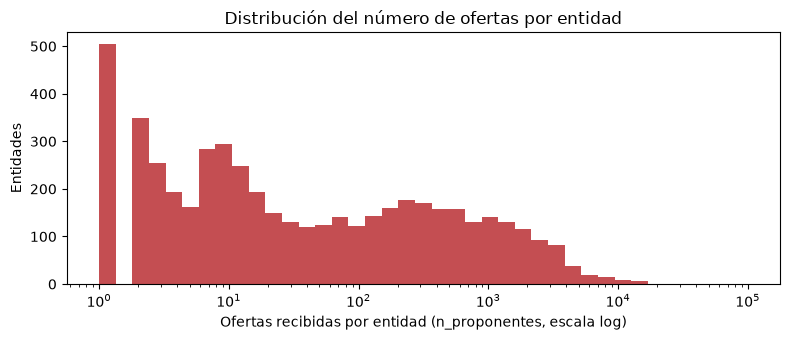

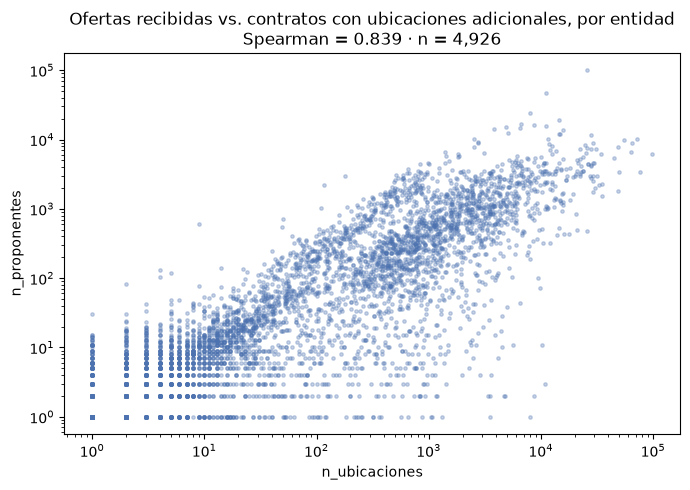

In [25]:
def dispersion(df, x, y, titulo, archivo, log_x=False, log_y=False):
    d = df[[x, y]].dropna()
    if log_x: d = d[d[x] > 0]
    if log_y: d = d[d[y] > 0]
    rho = d[x].rank().corr(d[y].rank())   # Spearman = Pearson sobre los rangos (no requiere scipy)
    fig, ax = plt.subplots(figsize=(7, 5))
    if len(d) > 50_000:
        hb = ax.hexbin(d[x], d[y], gridsize=60, bins="log", cmap="viridis",
                       xscale="log" if log_x else "linear", yscale="log" if log_y else "linear")
        fig.colorbar(hb, ax=ax, label="log10(n)")
    else:
        jx = np.random.default_rng(SEMILLA).uniform(-0.2, 0.2, len(d)) if d[x].nunique() < 30 else 0
        jy = np.random.default_rng(SEMILLA + 1).uniform(-0.2, 0.2, len(d)) if d[y].nunique() < 30 else 0
        ax.scatter(d[x] + jx, d[y] + jy, s=6, alpha=0.3, color="#4C72B0")
        if log_x: ax.set_xscale("log")
        if log_y: ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f"{titulo}\nSpearman = {rho:.3f} · n = {len(d):,}")
    guardar_fig(fig, archivo)

# ---------- Opción A ----------
SCATTER_A = {"base": "proponentes", "x": None, "y": None, "log_x": False, "log_y": False}   # COMPLETAR si aplica
if SCATTER_A["x"] and SCATTER_A["y"]:
    b = SCATTER_A["base"]
    mu = muestra_pd(LIMPIO[b], [SCATTER_A["x"], SCATTER_A["y"]])
    dispersion(mu, SCATTER_A["x"], SCATTER_A["y"], f"{SCATTER_A['y']} vs {SCATTER_A['x']} – {b}", f"scatter_A_{b}.png",
               SCATTER_A["log_x"], SCATTER_A["log_y"])

# ---------- Opción B: cruce por ENTIDAD ----------
# Las bases no comparten ID de proceso (CO1.REQ vs CO1.PCCNTR); se cruzan por la entidad compradora.
LLAVE_CRUCE = {"proponentes": "Codigo Entidad", "ubicaciones": "Codigo Entidad"}
A, B = list(RUTAS)   # "proponentes", "ubicaciones"

if all(LLAVE_CRUCE.values()):
    with Medir("ambas", "5. Agregación y cruce por entidad") as m:
        agregados = []
        for base, c in LLAVE_CRUCE.items():
            # se quitan comas/puntos: proponentes trae "702,962,226" y ubicaciones "702.962.226"
            agregados.append(LIMPIO[base].group_by(pl.col(c).cast(pl.Utf8).str.replace_all(r"[^0-9A-Za-z]", "").alias("entidad"))
                             .agg(pl.len().alias(f"n_{base}")).drop_nulls("entidad"))
        cruce = (agregados[0].join(agregados[1], on="entidad", how="left")
                 .with_columns(pl.col(f"n_{B}").fill_null(0)).collect())
        m.filas = cruce.height
    cruce.write_parquet(SALIDA / "agregado_por_entidad.parquet")
    display(cruce.select(pl.exclude("entidad")).describe())
    print(f"Entidades de {A} sin registros en {B}: {(cruce[f'n_{B}'] == 0).sum():,} de {cruce.height:,}")

    # Distribución del número de ofertas por entidad (muy asimétrica -> escala log)
    npro = cruce[f"n_{A}"].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(npro, bins=np.logspace(0, np.log10(npro.max()), 40), color="#C44E52")
    ax.set_xscale("log"); ax.set_xlabel(f"Ofertas recibidas por entidad (n_{A}, escala log)"); ax.set_ylabel("Entidades")
    ax.set_title("Distribución del número de ofertas por entidad")
    guardar_fig(fig, "dist_por_entidad.png")

    # Son ~5.000 entidades: no hace falta muestrear
    dispersion(cruce.to_pandas(), f"n_{B}", f"n_{A}",
               "Ofertas recibidas vs. contratos con ubicaciones adicionales, por entidad",
               "scatter_B_por_entidad.png", log_x=True, log_y=True)
else:
    print("Definir LLAVE_CRUCE para ejecutar la opción B.")


## Bitácora de rendimiento (requisito del curso)

In [26]:
bit = pd.DataFrame(BITACORA)
bit["MB"] = (bit["bytes"] / 2**20).round(1)
bit.to_csv(SALIDA / "bitacora_rendimiento.csv", index=False, encoding="utf-8-sig")
display(bit.drop(columns="bytes"))
print(f"\nMemoria total del equipo: {psutil.virtual_memory().total / 2**30:.1f} GB · núcleos: {os.cpu_count()}")

,base,etapa,segundos,ram_pico_mb,ram_adicional_mb,filas,MB
0,proponentes,Archivo CSV original,NaN,NaN,NaN,NaN,593.0
1,proponentes,CSV → Parquet crudo,1.11,1879.4,1384.4,2318975.0,102.1
2,ubicaciones,Archivo CSV original,NaN,NaN,NaN,NaN,1234.5
3,ubicaciones,CSV → Parquet crudo,2.88,1880.2,986.2,6081717.0,124.5
4,proponentes,1. Descripción de variables,0.68,1295.8,623.3,2318975.0,NaN
5,ubicaciones,1. Descripción de variables,1.48,2239.1,963.7,6081717.0,NaN
6,proponentes,4. Diagnóstico de calidad,1.66,2793.6,557.9,2318975.0,NaN
7,proponentes,4. Escritura Parquet limpio,1.59,3530.2,823.0,2283441.0,106.5
8,ubicaciones,4. Diagnóstico de calidad,5.82,4176.7,1893.6,6081717.0,NaN
9,ubicaciones,4. Escritura Parquet limpio,3.40,4523.8,1134.0,6081717.0,128.5



Memoria total del equipo: 15.2 GB · núcleos: 12


# Resumen: SECOP II Proponentes y Ubicaciones Adicionales

**Conclusión general:** Proponentes es útil, sobre todo para detectar baja competencia. Ubicaciones aporta poco por sí sola. Ninguna de las dos trae valores, modalidad ni estado del proceso, así que ambas requieren complementarse con otras bases de SECOP II.

## 1. Descripción de variables y propósito
- **Proponentes** (2,3 M filas × 9 columnas): cada fila es una oferta de un proveedor en un proceso. Columnas: proceso (ID, nombre, fecha de publicación 2015-2026), entidad (NIT, código, nombre) y proveedor (NIT, código, nombre). **Propósito:** saber quién compite en cada proceso.
- **Ubicaciones** (6,1 M filas × 11 columnas): cada fila es un contrato y dónde se ejecuta. Columnas: contrato (ID, referencia), entidad (NIT, código, nombre) y ubicación (departamento, ciudad, dirección y sus versiones "Original"). **Propósito:** saber dónde se ejecutan los contratos.

## 2. Tendencia central y distribución
- No hay variables numéricas; se analizaron frecuencias y conteos agregados.
- 698 mil procesos con **3,3 ofertas por proceso** en promedio; 339 mil proveedores y 5.020 entidades.
- Las ofertas crecen cada año (≈ 4 mil en 2016 → ≈ 370 mil en 2025), con una caída en 2022.
- Hay alta concentración por entidad: mediana de 20 ofertas frente a una media de 455. INVIAS sola recibe el 4,4 % de las ofertas.
- Bogotá concentra ≈ 18 % de los contratos en Ubicaciones.

## 3. Correlación y mapas de calor
- **Pearson / Spearman:** no aplican (no hay variables numéricas).
- **V de Cramér:** no aplica (las categóricas tienen cientos o miles de categorías).
- Solo se pudo correlacionar con variables agregadas por entidad (ver punto 5).

## 4. Limpieza: nulos, ceros y duplicados
- **Duplicados:** 35.534 en Proponentes (1,5 %), eliminados. Ubicaciones: 0.
- **Nulos:** NIT Proveedor 10 % (consorcios); fecha de publicación 0,7 %; Dirección ≈ 90 % ("No Provisto"); Departamento 2 %.
- **Ceros:** no aplica (no hay numéricas).
- **Otros problemas:** Departamento y Ciudad vienen **invertidos**, las tildes están dañadas ("BOGOTa") y el NIT tiene formatos distintos entre bases (`901,541,245` frente a `899.999.027`).

## 5. Cruce de dos variables (scatter)
- Número de ofertas recibidas frente a número de contratos con ubicación, **por entidad**.
- **Spearman = 0,84** (4.926 entidades): relación fuerte, explicada sobre todo por el tamaño de la entidad.
- Las entidades con muchos contratos y pocas ofertas son las más interesantes para revisar.

## 6. Llaves
| Base | Llave primaria | Cruce entre ambas |
|---|---|---|
| Proponentes | `ID Procedimiento` + `Codigo Proveedor` | `Codigo Entidad` (98 % de coincidencia) |
| Ubicaciones | `ID Contrato` | `Codigo Entidad` (75 % de coincidencia) |

- **No cruzan por proceso:** Proponentes usa IDs `CO1.REQ...` y Ubicaciones `CO1.PCCNTR...`.
- Para unirlas a nivel de proceso o contrato hace falta una base puente (Contratos o Procesos SECOP II).

## Utilidad para los enfoques
| Enfoque | Proponentes | Ubicaciones |
|---|---|---|
| **Contraloría** | ✅ Procesos con un solo oferente y concentración de proveedores | ➖ Poco |
| **Proveedores** | ✅ Historial de ofertas de cada proveedor | ✅ Región de ejecución |
| **Desiertos** | ⚠️ No indica el estado del proceso, y los procesos sin ofertas no aparecen | ❌ No |

